# Etap 3 - Deep learning: U-Net (PyTorch)

## 1. Przygotowanie środowiska

In [1]:
import sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

from src import io_utils, metrics, visualize, unet
from src.config import (
    TRAIN_IMAGES, TEST_IMAGES, RANDOM_SEED,
    MODELS_DIR, RESULTS_DIR,
)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = unet.get_device()

## 2. Przygotowanie zbioru danych

In [ ]:
VAL_IMAGES_INNER = TRAIN_IMAGES[:6]
TRAIN_IMAGES_INNER = TRAIN_IMAGES[6:]
print(f'inner train: {len(TRAIN_IMAGES_INNER)} obrazów')
print(f'inner val: {len(VAL_IMAGES_INNER)} obrazów = {VAL_IMAGES_INNER}')

CROP_SIZE = 256
CROPS_PER_TRAIN_IMAGE = 64
CROPS_PER_VAL_IMAGE = 16

train_ds = unet.RetinaPatchDataset(
    TRAIN_IMAGES_INNER, loader=io_utils.load_triplet,
    crop_size=CROP_SIZE, crops_per_image=CROPS_PER_TRAIN_IMAGE,
    vessel_prob=0.5, seed=RANDOM_SEED,
)
val_ds = unet.RetinaPatchDataset(
    VAL_IMAGES_INNER, loader=io_utils.load_triplet,
    crop_size=CROP_SIZE, crops_per_image=CROPS_PER_VAL_IMAGE,
    vessel_prob=0.5, seed=RANDOM_SEED+1,
)
print(f'train_ds: {len(train_ds)} kropów, val_ds: {len(val_ds)} kropów')

inner train: 33 obrazów
inner val:   6 obrazów = ['01_h', '02_h', '03_h', '04_h', '05_h', '06_h']
train_ds: 2112 kropów, val_ds: 96 kropów


## 3. DataLoader i model

In [ ]:
BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS,
)

model = smp.Unet(encoder_name='resnet34', encoder_weights="imagenet", in_channels=3, classes=1).to(device)

## 4. Uczenie

In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / 'unet.pt'

EPOCHS = 30
LR = 1e-3

t0 = time.time()
history = unet.train(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    save_best_to=model_path, progress=True,
)
print(f'\nUczenie zajęło {(time.time()-t0)/60:.1f} min')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21
: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data
_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data
_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

...

epoch  28: train_loss=0.3190  val_loss=0.2879  val_gmean=0.8908

epoch  29: train_loss=0.3209  val_loss=0.2410  val_gmean=0.9059

epoch  30: train_loss=0.3173  val_loss=0.2753  val_gmean=0.8919

`Trainer.fit` stopped: `max_epochs=30` reached.



Uczenie zajęło 52.8 min


### 4.1 Wykres uczenia

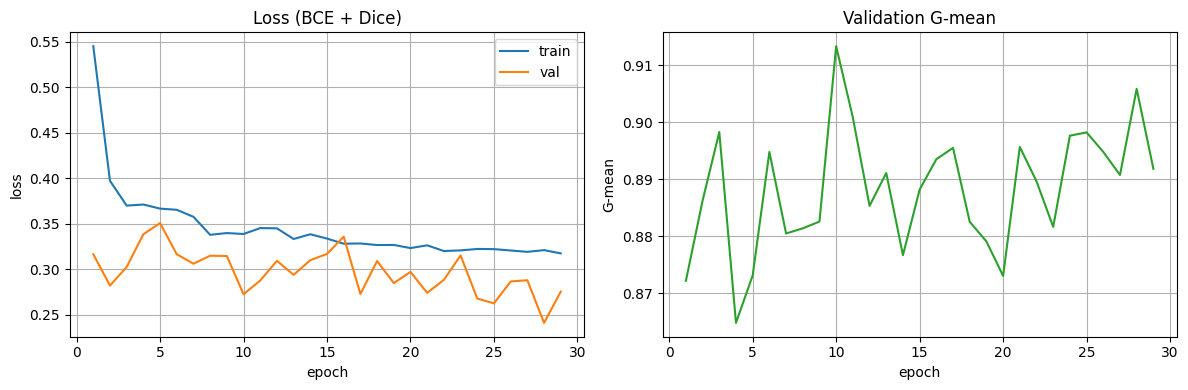

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.train_loss) + 1)
ax[0].plot(ep, history.train_loss, label='train')
ax[0].plot(ep, history.val_loss,   label='val')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend(); ax[0].grid(True)
ax[0].set_title('Loss (BCE + Dice)')
ax[1].plot(ep, history.val_gmean, color='tab:green')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('G-mean'); ax[1].grid(True)
ax[1].set_title('Validation G-mean')
fig.tight_layout(); plt.show()

## 5. Predykcja na obrazach testowych

Najlepszy checkpoint + tiling 256 z overlapem 32 na tych samych `TEST_IMAGES`.

In [8]:
best_model = unet.load_model(
    model_path, in_channels=3, out_channels=1, encoder='resnet34', device=device,
)

per_image = {}
predictions = {}
for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    t0 = time.time()
    pred = unet.predict_mask(
        best_model, img, fv, device=device,
        tile_size=256, overlap=32, threshold=0.5,
    )
    m = metrics.compute_metrics(pred, gt, fv)
    per_image[image_id] = m
    predictions[image_id] = (img, gt, fv, pred)
    print(f'{image_id}: {time.time()-t0:5.1f}s  '
          f'acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
          f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

agg = metrics.aggregate(list(per_image.values()))
for k in ['accuracy', 'sensitivity', 'specificity', 'g_mean']:
    print(f'  {k:20s} = {agg[k+"_mean"]:.4f} +- {agg[k+"_std"]:.4f}')

/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result 

14_h:   3.4s  acc=0.9707  sens=0.8756  spec=0.9817  g_mean=0.9271


/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result 

15_h:   2.8s  acc=0.9755  sens=0.8056  spec=0.9929  g_mean=0.8943


/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result 

...

15_dr:   2.6s  acc=0.9620  sens=0.8396  spec=0.9722  g_mean=0.9035


/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result 

14_g:   2.7s  acc=0.9612  sens=0.8003  spec=0.9758  g_mean=0.8837


/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/Users/illiayanukovich/Documents/DnoOka/venv/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result 

15_g:   2.7s  acc=0.9575  sens=0.8573  spec=0.9670  g_mean=0.9105
  accuracy             = 0.9646 +- 0.0069
  sensitivity          = 0.8286 +- 0.0340
  specificity          = 0.9779 +- 0.0089
  g_mean               = 0.8999 +- 0.0175


### 5.1 Porównanie wizualne

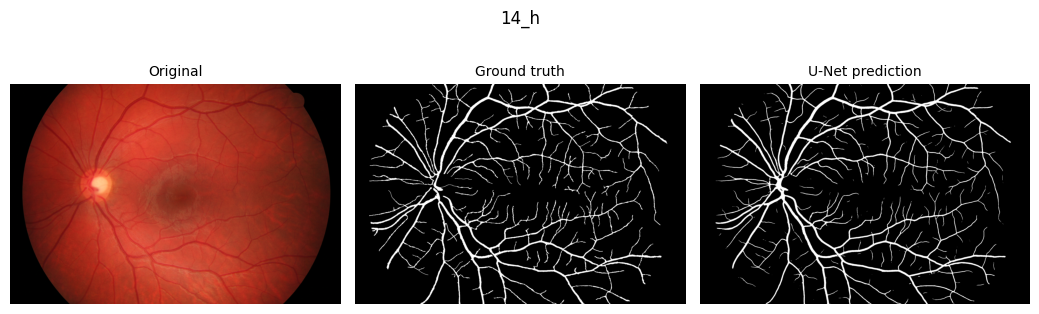

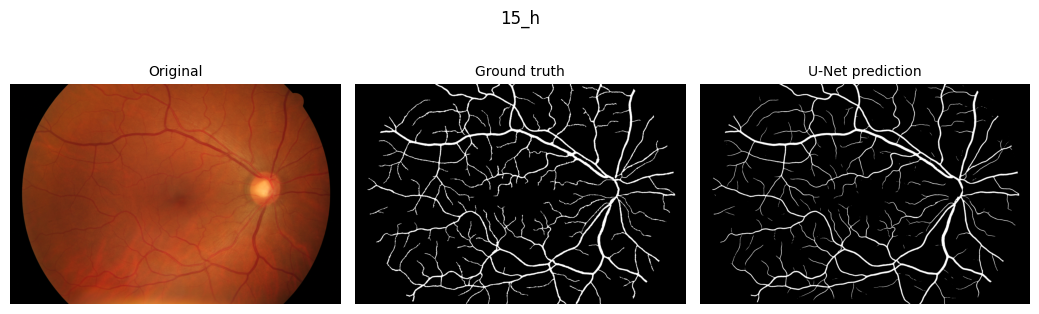

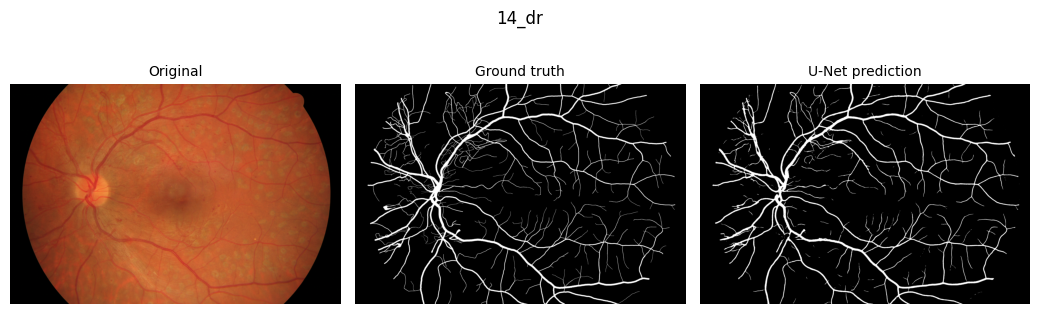

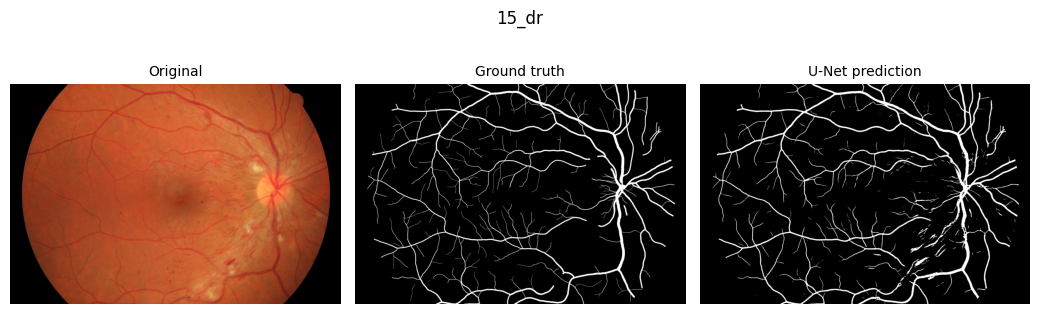

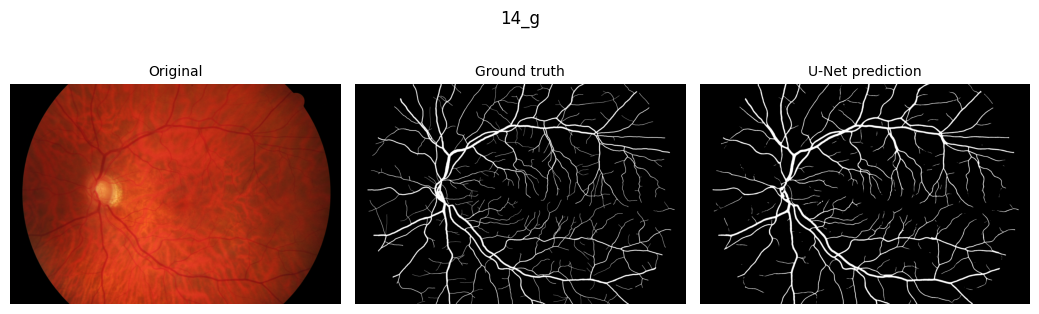

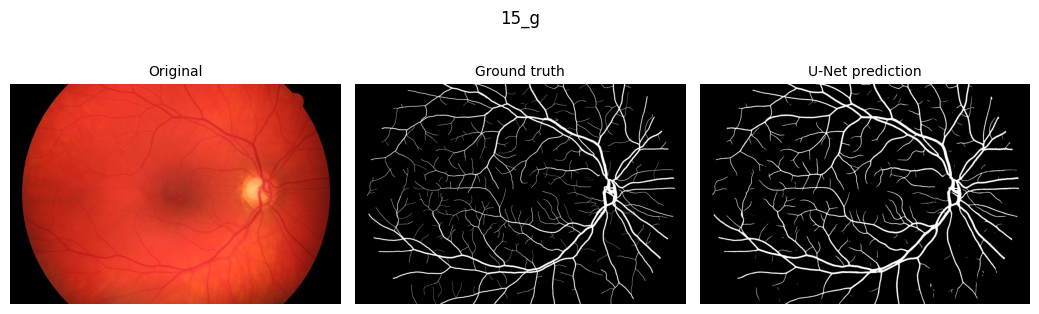

In [7]:
for image_id in TEST_IMAGES:
    img, gt, fv, pred = predictions[image_id]
    fig = visualize.compare_grid([
        ('Original', img),
        ('Ground truth', gt * 255),
        ('U-Net prediction', pred * 255),
    ], ncols=3, suptitle=image_id, figsize_per_panel=(3.5, 3.5))
    plt.show()